<a href="https://colab.research.google.com/github/TRACE-Structures/digital_twinning/blob/main/demo/notebooks/multimodel_pilot_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Multi-Building Design Update of CLT buildings**

This Jupyter Notebook demonstrates how to use the joint **Multi-Model Update** with the example of two, previously trained models of two Tall Timber Buildings: the Yoker and Palisaden buildings (see the notebook on Hybrid Digital Twinning of the Yoker Building [here](https://github.com/TRACE-Structures/digital_twinning/blob/main/demo/notebooks/hybrid_pilot_example.ipynb)).

The main objective of the Multi-Building Updating is to calibrate uncertain parameters of simulation models across multiple buildings or experimental setups using shared measurement data. This ensemble-based calibration improves generalizability and robustness compared to single-structure updates.


In [ ]:
! pip install digital_twinning

In [2]:
import pickle
import pandas as pd
import digital_twinning as dt

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Load models

In this example we simply load two previusly trained hybrid models of the two system. The chosen parameters of the models were the following:

- Yoker: elastic moduli of the CLT panels in the three major strength directions ($e_{1}$, $e_{2}$, $e_{3}$), two in-plane shear moduli ($g_{1}$, $g_{2}$) and the distributed mass ($q$).
- Palisaden: scaling factor for the vertical elastic moduli of the CLT walls ($γ_{e_{1}}$), scaling factor for the in-plane shear stiffness of the walls ($γ_{G_{12}}$), additional scaling factor used for the external walls to  account for the increased  shear stiffness of these walls due to the facade ($γ_{G_{12,ext}}$), stiffness parameter of the foundation beneath the ground floor ($k_{spring}$) and a scaling factor of the initially estimated total mass of the building ($γ_{ρ}$)

The models are connected through the **$e_{1}$** and $γ_{e_{1}}$ parameters

In [3]:
import requests, io

yoker_path = 'https://raw.githubusercontent.com/TRACE-Structures/digital_twinning/main/demo/data/Yoker_building/'
palisaden_path = 'https://raw.githubusercontent.com/TRACE-Structures/digital_twinning/main/demo/data/Palisaden/'

#Load measurement data
z_yoker = pd.read_csv(yoker_path + 'z_m_df.csv')
z_palisaden = pd.read_csv(palisaden_path + 'z_m_df.csv')

#Load standard deviation of the measurement error
sigma_yoker = pd.read_csv(yoker_path + 'sigma.csv')
sigma_palisaden = pd.read_csv(palisaden_path + 'sigma.csv')

def load_pickle_from_url(url):
    response = requests.get(url)
    response.raise_for_status()
    return pickle.load(io.BytesIO(response.content))

model_path = 'https://raw.githubusercontent.com/TRACE-Structures/digital_twinning/main/demo/data/models/'

#Load surrogate models
Yoker_model = load_pickle_from_url(model_path + 'Yoker_model.sm')
Palisaden_model = load_pickle_from_url(model_path + 'Palisaden_model.sm')

# Update

In [4]:
#Define joint parameters
joint_parameters = {'joint_e1_COEF_VERT': ['e1', 'COEF_VERT']}

#Define the joint manager
j = dt.JointManager([Yoker_model, Palisaden_model], joint_parameters)
print(j.Q.variables)

{'joint_e1_COEF_VERT': U(-1, 1), 'e2': U(-1, 1), 'e3': U(-1, 1), 'g1': U(-1, 1), 'g2': U(-1, 1), 'q': U(-1, 1), 'COEF_G': U(-1, 1), 'FACADE': U(-1, 1), 'FOUNDATION': U(-1, 1), 'WEIGHT': U(-1, 1)}


In [5]:
nwalkers=32
niter=200
nburn=1000


j.update([z_yoker, z_palisaden], [sigma_yoker, sigma_palisaden], nwalkers=nwalkers, niter=niter, nburn=nburn)

MCMC creating
Burning period


100%|██████████| 1000/1000 [02:19<00:00,  7.19it/s]


MCMC running


100%|██████████| 200/200 [00:27<00:00,  7.21it/s]

--- 166.93943095207214 seconds ---


# Results

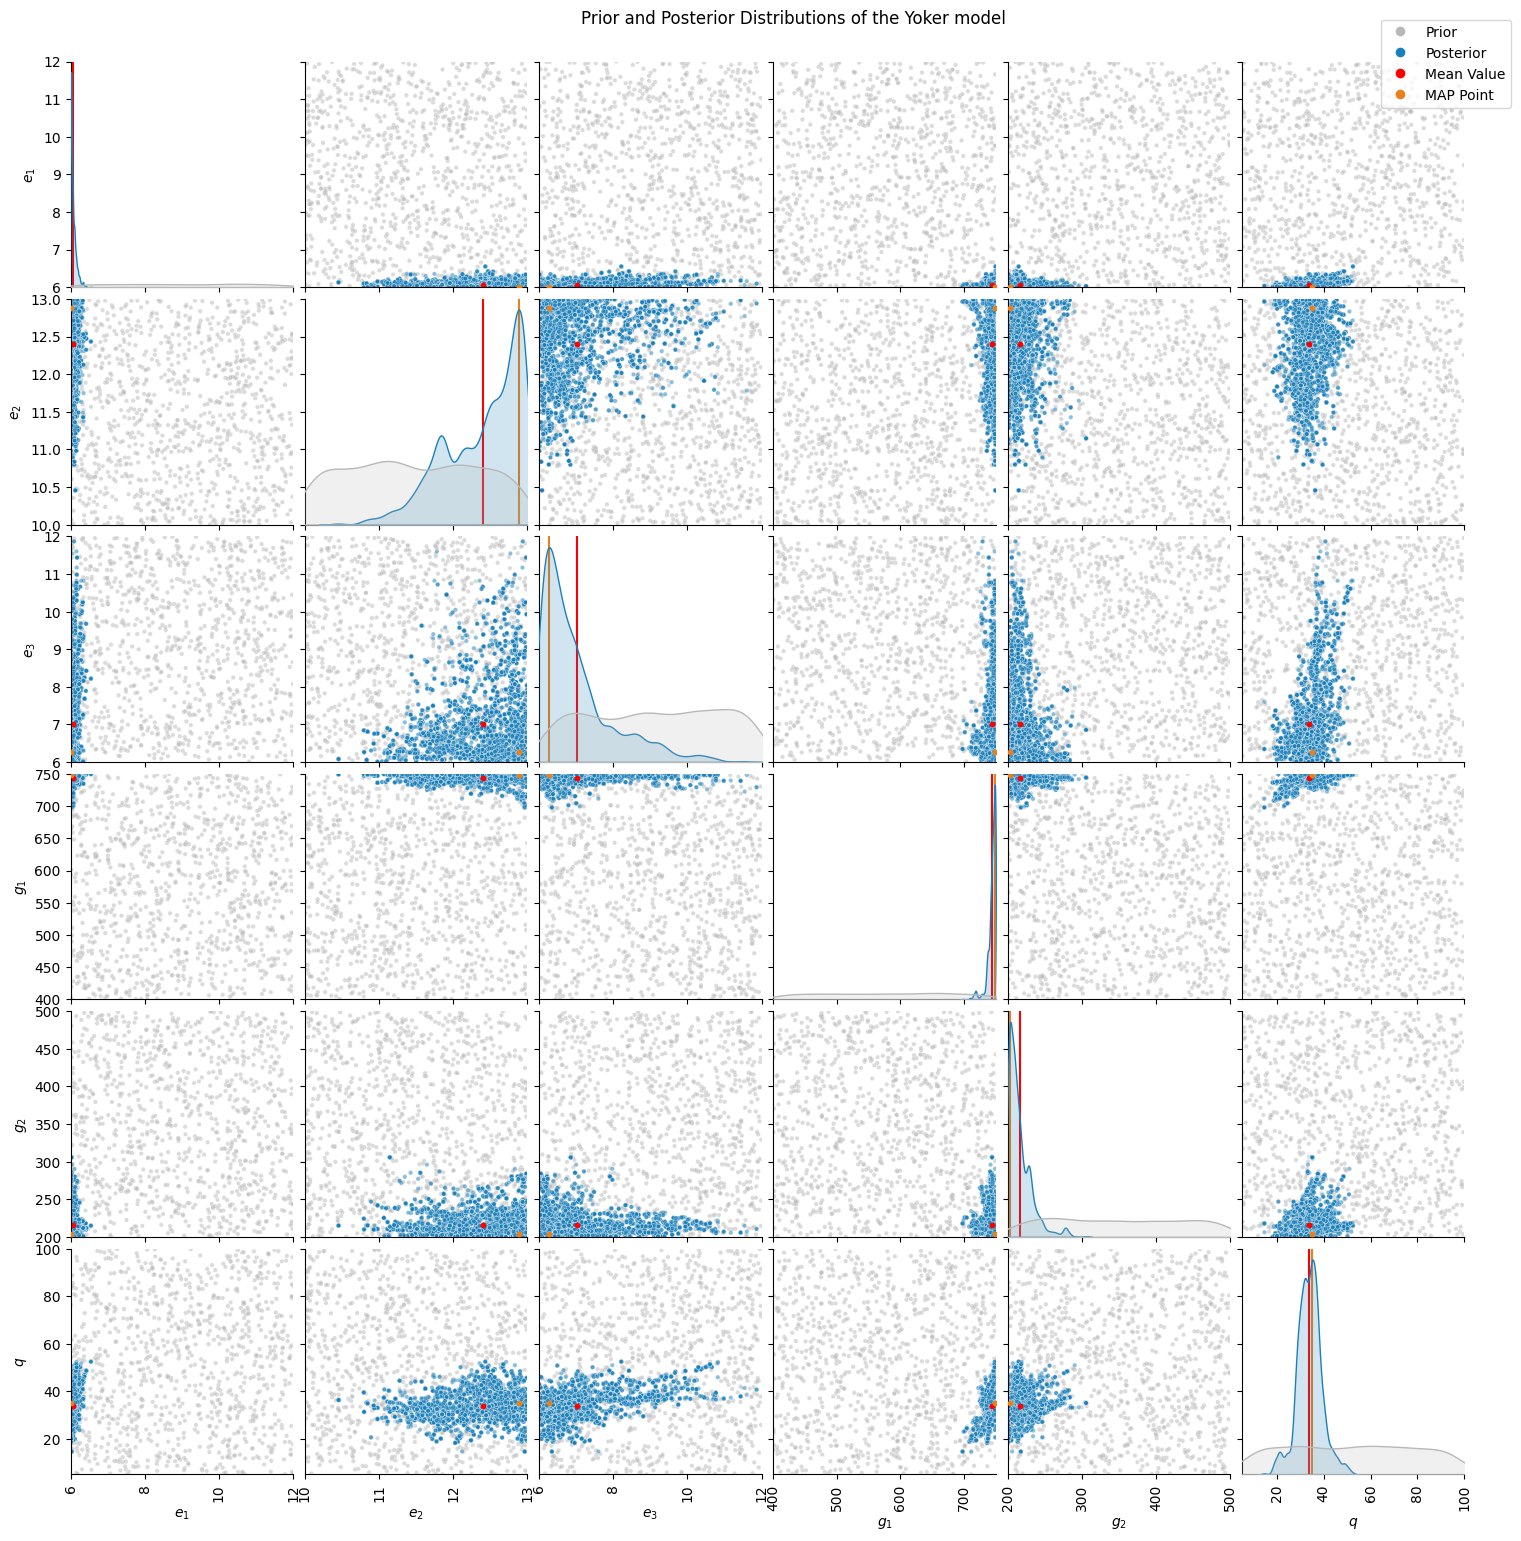

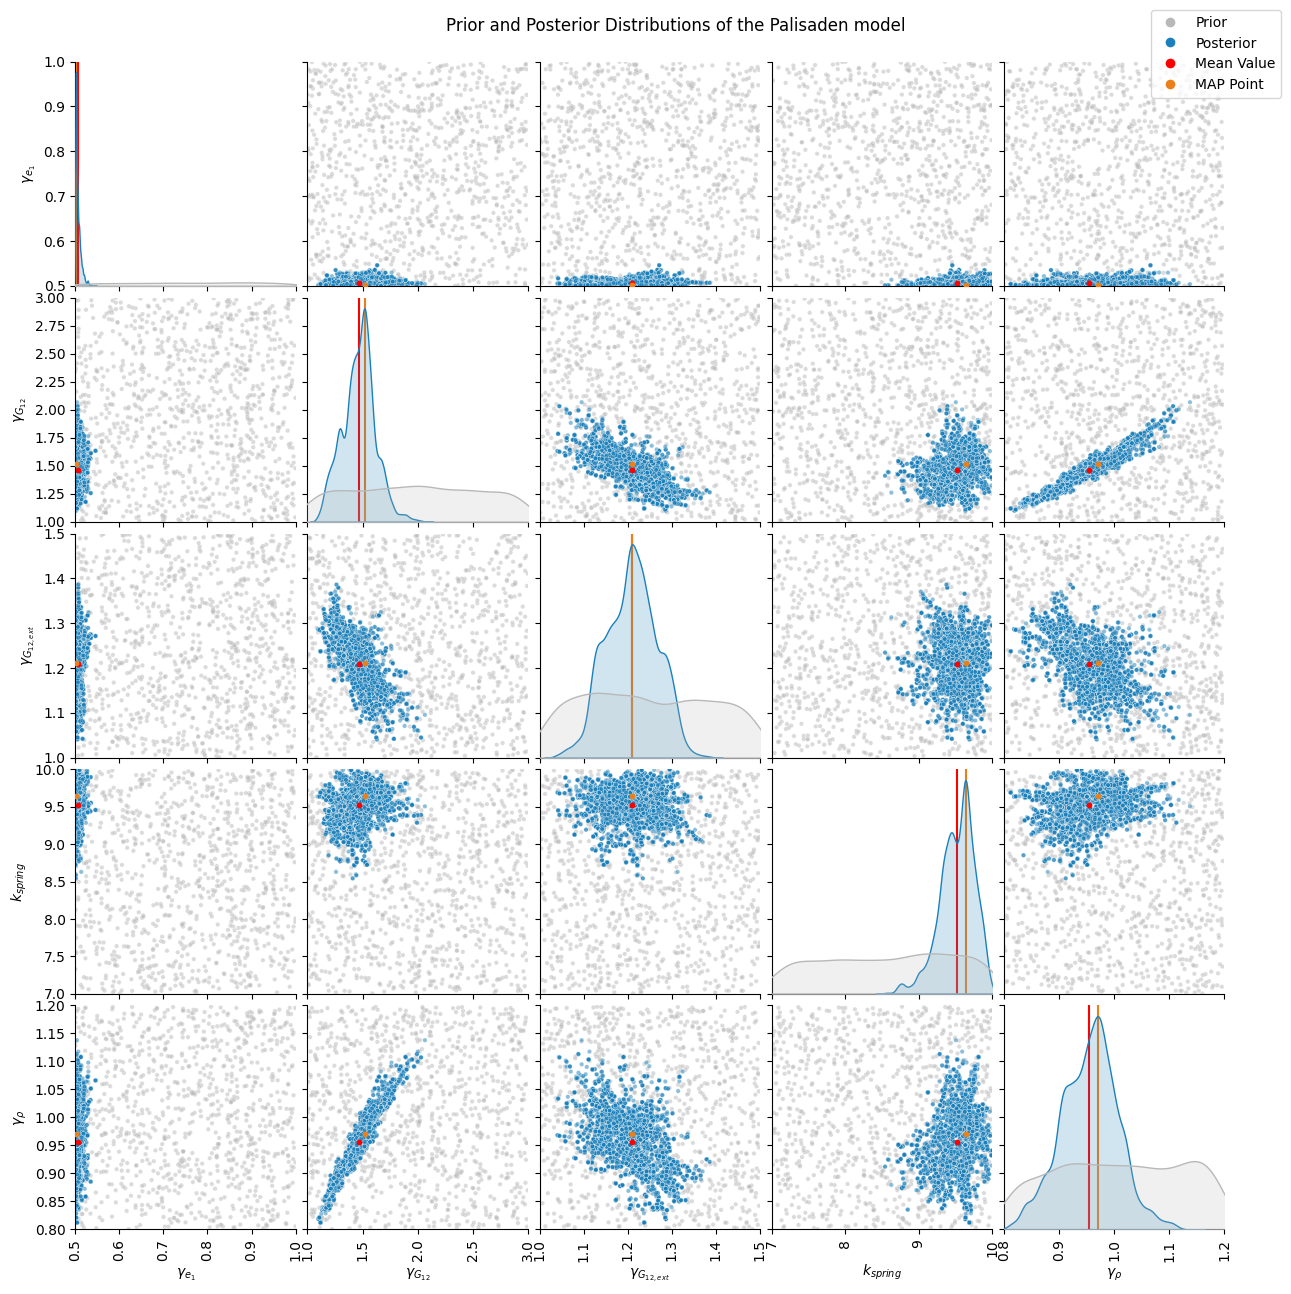

In [6]:
figs = dt.plot_multimodel_MCMC(j, map_point=True, model_names=['Yoker', 'Palisaden'], formatted_param_names=[["$e_{1}$", "$e_{2}$", "$e_{3}$", "$g_{1}$", "$g_{2}$", '$q$'], ["$γ_{e_{1}}$", "$γ_{G_{12}}$", "$γ_{G_{12,ext}}$", "$k_{spring}$", "$γ_{ρ}$"]])

In [7]:
model_index = 0
map_point, mean, variance, posterior_samples = j.get_data_of_model(model_index)

In [8]:
map_point

,e1,e2,e3,g1,g2,q
0,6.016595,12.883826,6.266518,748.419799,203.725959,35.130145


In [9]:
mean

,e1,e2,e3,g1,g2,q
0,6.067682,12.396889,7.009759,743.736475,216.137333,33.760482


In [10]:
variance

,e1,e2,e3,g1,g2,q
0,9.001741,11.672873,9.330705,575.275696,351.731736,53.101626


In [11]:
posterior_samples

,e1,e2,e3,g1,g2,q
0,6.044829,11.588220,7.062155,749.280199,201.036848,33.527424
1,6.026518,12.751373,7.830520,747.423869,218.104915,37.496131
2,6.078915,11.798998,6.974459,748.464937,212.685889,40.574601
3,6.147060,11.906992,6.431660,736.793391,232.911475,25.652429
4,6.012677,11.669604,6.266340,748.847044,208.161722,30.416113
...,...,...,...,...,...,...
6395,6.128176,12.871138,7.256156,740.737830,218.842675,38.768967
6396,6.048690,12.882074,6.079838,744.839779,200.928644,25.794919
6397,6.012245,12.058589,6.422422,749.097781,200.914419,27.535745
6398,6.019207,12.837329,7.340012,742.346482,212.365715,35.711468
